# Master of Telegram Ads: VIEWS forecasting - EDA


## Notebook scope

This notebook documents **EDA findings** and the decisions that impact model quality for forecasting `VIEWS`.

**Production constraint:** at inference time, only `CPM`, `CHANNEL_NAME`, `DATE` are available.  
Columns like `AD_ID`, `CLICKS`, `ACTIONS` can be analyzed, but **must not be used** as inference features.

The notebook is organized into 10 sections: data sanity checks -> distributions -> time/channels -> baselines -> modeling conclusions.

### 1. Imports and data loading

**What we do:** load the training dataset (`AllData.csv`) and make sure it is read correctly.

**Outcome:** a `DataFrame df` in memory, ready for data quality checks and further EDA.

In [223]:
# import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import timedelta

In [224]:
# Load data
path = "data/AllData.csv"
df = pd.read_csv(path)
df.head() # viewing first 5 rows

,AD_ID,CPM,VIEWS,CLICKS,ACTIONS,CHANNEL_NAME,DATE
0,3652,1.2,52,0,0,tanya_in_france,2024-10-02
1,3653,1.2,54,2,0,relocator_cc,2024-10-02
2,3654,1.2,15,1,0,teleportazia,2024-10-02
3,3655,1.5,85,2,1,spetsialist_visa_support,2024-10-02
4,3656,19.4,688,21,3,pitkvch_news,2024-10-02


### 2. Quick data quality checks (missing values, dtypes, size)

**What we do:** check missing values, data types, and dataset size.

**Outcome:** basic dataset “health” confirmation.

In [225]:
df.shape # Information about shape of Data Frame 

(142609, 7)

In [226]:
df.isna().sum() # Data for training does not have empty cells

AD_ID            0
 CPM             0
 VIEWS           0
 CLICKS          0
 ACTIONS         0
 CHANNEL_NAME    0
 DATE            0
dtype: int64

In [227]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 142609 entries, 0 to 142608
Data columns (total 7 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   AD_ID          142609 non-null  int64  
 1    CPM           142609 non-null  float64
 2    VIEWS         142609 non-null  int64  
 3    CLICKS        142609 non-null  int64  
 4    ACTIONS       142609 non-null  int64  
 5    CHANNEL_NAME  142609 non-null  object 
 6    DATE          142609 non-null  object 
dtypes: float64(1), int64(4), object(2)
memory usage: 7.6+ MB


In [228]:
df.dtypes # CHANNEL_NAME, DATE are object types;
# All others are float or int

AD_ID              int64
 CPM             float64
 VIEWS             int64
 CLICKS            int64
 ACTIONS           int64
 CHANNEL_NAME     object
 DATE             object
dtype: object

### 3. `DATE` preprocessing and time coverage

**What we do:** parse `DATE` into datetime and inspect date range / number of unique days.

**Outcome:** confidence that time-based splitting is feasible.

In [229]:
df.columns = df.columns.str.strip() # Deleting space in column names

In [230]:
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")
df.dtypes # Converting from object to data types

AD_ID                    int64
CPM                    float64
VIEWS                    int64
CLICKS                   int64
ACTIONS                  int64
CHANNEL_NAME            object
DATE            datetime64[ns]
dtype: object

In [231]:
# Date range: 2024-10-02 -> 2025-12-17 (430 days)
df["DATE"].min(), df["DATE"].max(), df["DATE"].nunique()

(Timestamp('2024-10-02 00:00:00'), Timestamp('2025-12-17 00:00:00'), 430)

### 4. Distributions and heavy tails (`VIEWS`, `CPM`)

**What we do:** inspect quantiles and distributions of `VIEWS` and `CPM` in linear and log scales.

**Why it matters:** heavy tails usually require `log1p(VIEWS)` (target) and `log1p(CPM)` / clipping (features).

**Outcome:** decide which transforms are needed before modeling.

In [232]:
num_cols = ["CPM", "VIEWS", "CLICKS", "ACTIONS"] # int or float columns
df[num_cols].describe(percentiles=[0.5, 0.9, 0.95, 0.99])# Description of columns with numbers

,CPM,VIEWS,CLICKS,ACTIONS
count,142609.000000,1.426090e+05,142609.000000,142609.000000
mean,8.994971,9.998400e+02,13.245714,4.478245
std,29.404112,7.260922e+03,211.894919,159.825803
min,1.000000,0.000000e+00,0.000000,0.000000
50%,3.530000,2.550000e+02,1.000000,0.000000
90%,19.900000,1.642000e+03,16.000000,3.000000
95%,29.700000,3.196600e+03,35.000000,8.000000
99%,63.000000,1.199692e+04,183.000000,49.000000
max,999.910000,1.136470e+06,48513.000000,37978.000000


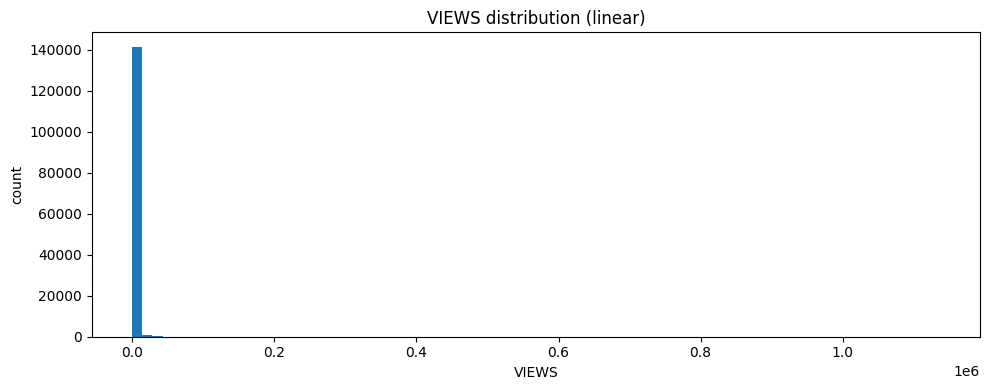

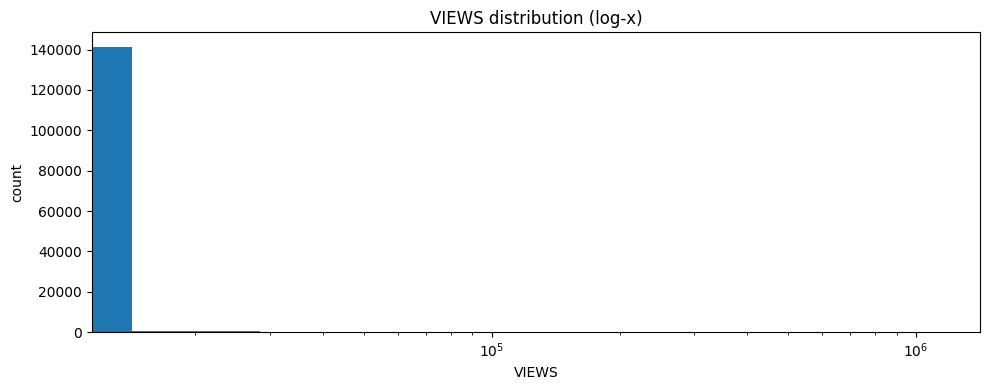

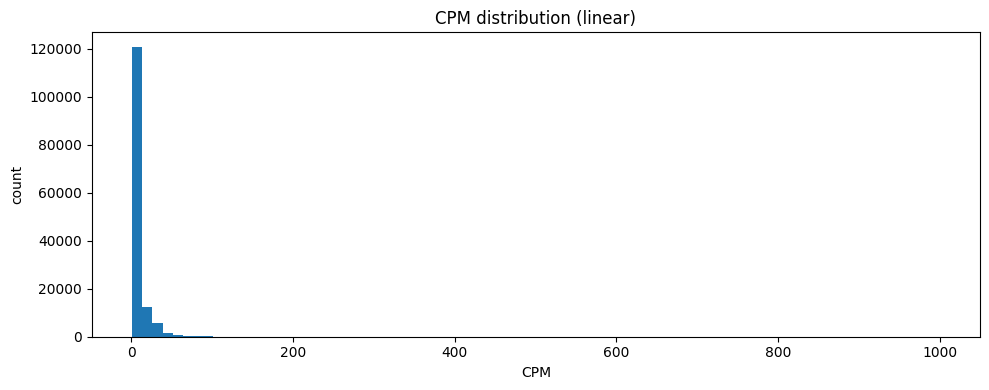

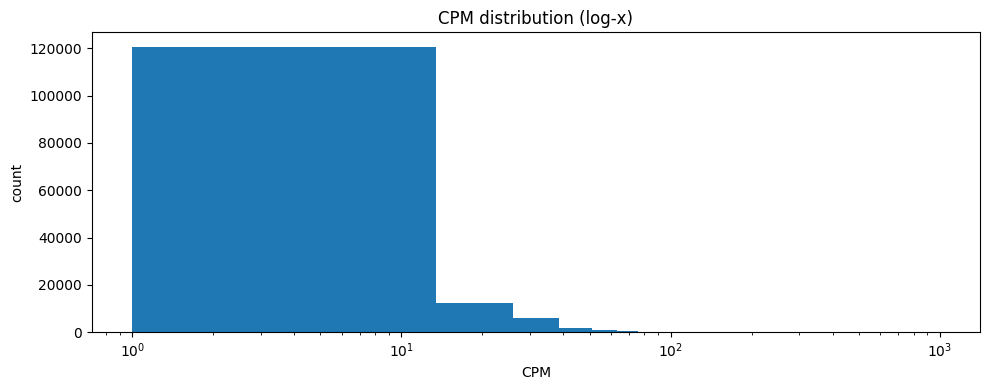

In [233]:
def plot_hist(series, title, bins=80, logx=False):
    s = series.dropna().astype(float)
    plt.figure(figsize=(10,4))
    plt.hist(s, bins=bins)
    plt.title(title)
    plt.xlabel(series.name)
    plt.ylabel("count")
    if logx:
        plt.xscale("log")
    plt.tight_layout()
    plt.show()
# Plotting default VIEWS.values
plot_hist(df["VIEWS"], "VIEWS distribution (linear)")
plot_hist(df["VIEWS"], "VIEWS distribution (log-x)", logx=True)
plot_hist(df["CPM"], "CPM distribution (linear)")
plot_hist(df["CPM"], "CPM distribution (log-x)", logx=True)

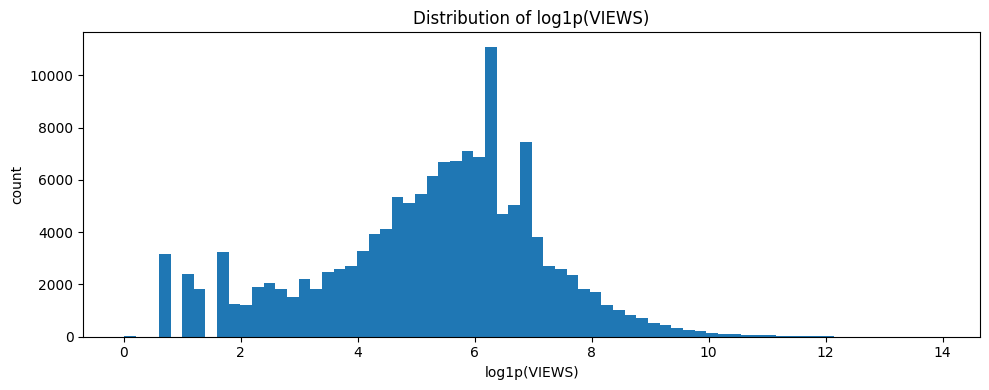

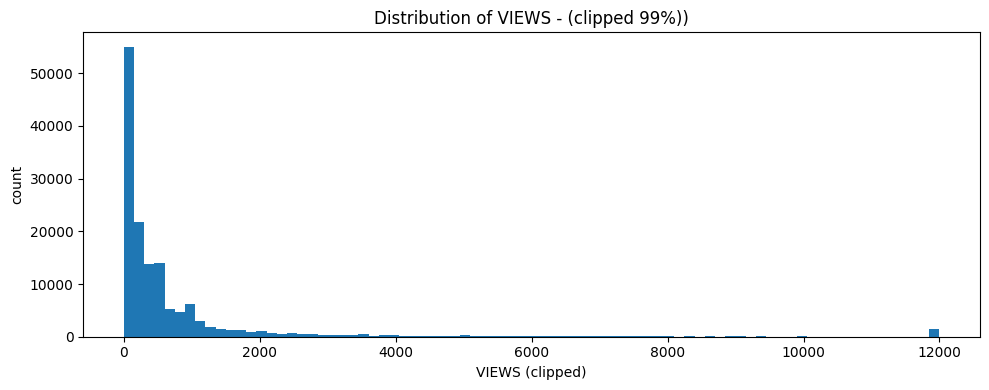

In [234]:
# Histogram where instead of VIEWS.values we use a function of these values log1p(VIEWS.values)
plt.figure(figsize=(10,4))
plt.hist(np.log1p(df["VIEWS"].values), bins=70)
plt.title("Distribution of log1p(VIEWS)")
plt.xlabel("log1p(VIEWS)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

# To better display the graph -> trim the extreme part 
p99 = np.quantile(df["VIEWS"].values, 0.99)
views_values_99 = np.clip(df["VIEWS"].values, 0, p99)

plt.figure(figsize=(10,4))
plt.hist(views_values_99, bins=80)
plt.title("Distribution of VIEWS - (clipped 99%))")
plt.xlabel("VIEWS (clipped)")
plt.ylabel("count")
plt.tight_layout()
plt.show()

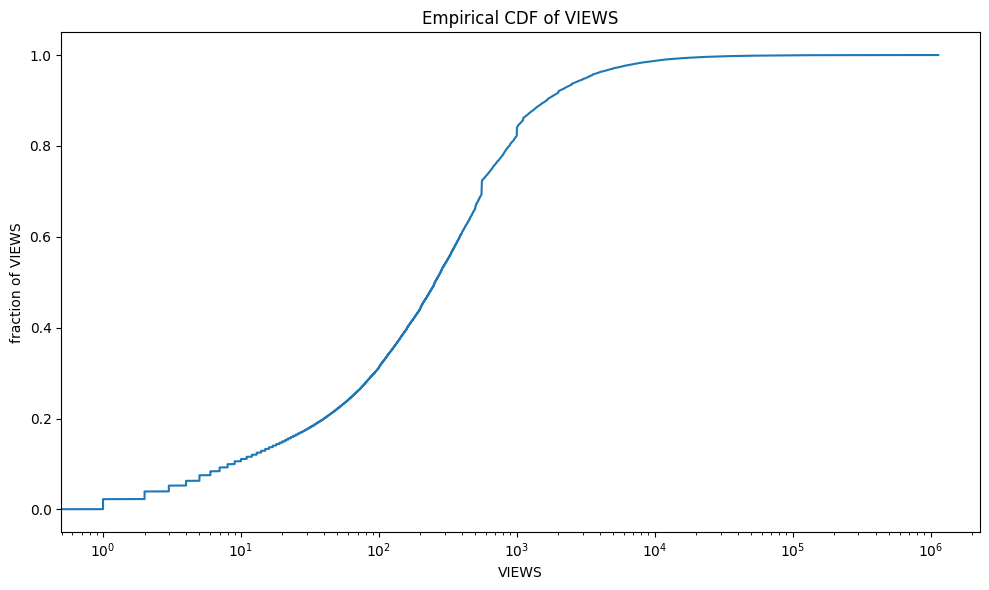

In [235]:
views_values = np.sort(df["VIEWS"].values)
fraction = np.arange(1, len(views_values)+1) / len(views_values) # for Empirical CDF

plt.figure(figsize=(10,6))
plt.plot(views_values, fraction)
plt.xscale("log")  # важно
plt.title("Empirical CDF of VIEWS")
plt.xlabel("VIEWS")
plt.ylabel("fraction of VIEWS")
plt.tight_layout()
plt.show()

### 5. Relationship `CPM → VIEWS` (signal vs noise)

**What we do:** visualize the relationship (preferably in log scale) to see how much CPM explains `VIEWS`.

**Outcome:**
- whether the relationship looks monotonic or saturating;
- how large the variance is at similar CPM levels.

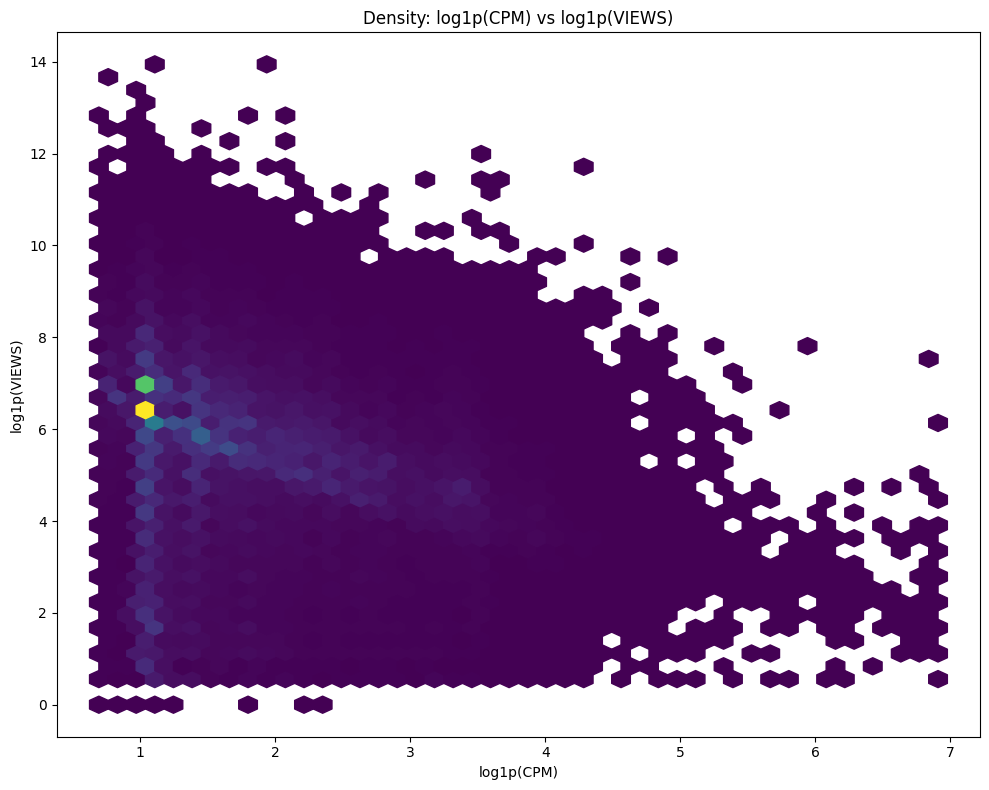

In [236]:
log_cpm = np.log1p(df["CPM"]) # log1p(CPM.values)
log_views = np.log1p(df["VIEWS"]) # log1p(VIEWS.values)

plt.figure(figsize=(10,8))
plt.hexbin(log_cpm, log_views, gridsize=45, mincnt=1) # hexbin density to see correlation between CPM and VIEWS
plt.title("Density: log1p(CPM) vs log1p(VIEWS)")
plt.xlabel("log1p(CPM)")
plt.ylabel("log1p(VIEWS)")
plt.tight_layout()
plt.show()

In [237]:
np.corrcoef(log_cpm, log_views)[0,1] # correlation coefficient

-0.1708494933727653

### 6. Time dynamics and seasonality

**What we do:** Aggregate by day and inspect activity over time + day-of-week effect.

**Outcome:** detect non-stationarity and basic seasonality patterns.

In [238]:
daily = (df.groupby("DATE", as_index=False).agg(
            rows=("VIEWS","size"),
            views_sum=("VIEWS","sum"),
            views_median=("VIEWS","median"),
            cpm_median=("CPM","median"))
        )
daily.head()

,DATE,rows,views_sum,views_median,cpm_median
0,2024-10-02,20,2396,53.0,1.2
1,2024-10-03,40,4222,93.0,1.0
2,2024-10-04,21,27365,1014.0,3.0
3,2024-10-06,2,2,1.0,100.0
4,2024-10-07,824,1872867,718.0,1.6


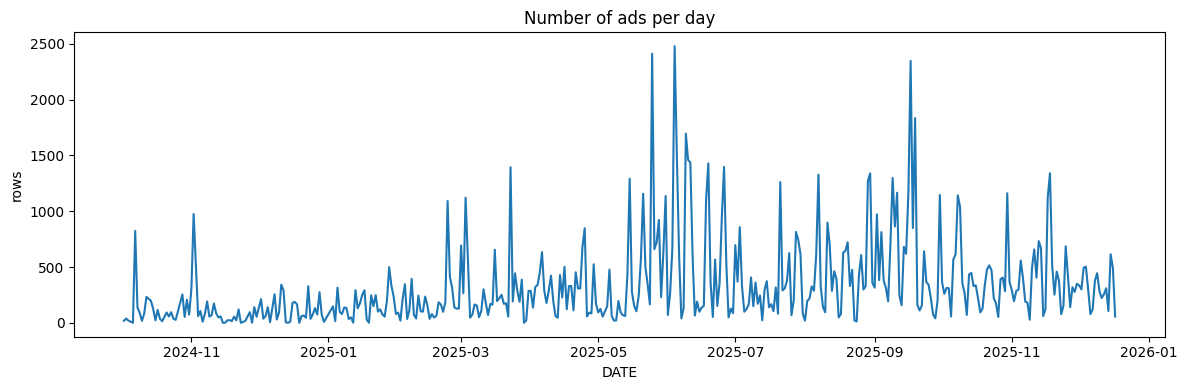

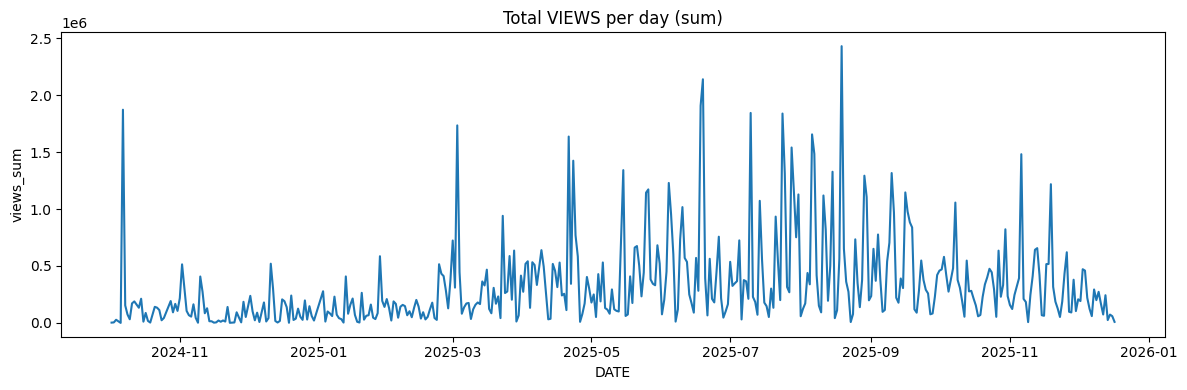

In [239]:
plt.figure(figsize=(12,4))
plt.plot(daily["DATE"], daily["rows"])
plt.title("Number of ads per day")
plt.xlabel("DATE")
plt.ylabel("rows")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(daily["DATE"], daily["views_sum"])
plt.title("Total VIEWS per day (sum)")
plt.xlabel("DATE")
plt.ylabel("views_sum")
plt.tight_layout()
plt.show()

In [240]:
df["DOW"] = df["DATE"].dt.dayofweek  # 0 - Monday, etc
dow_stats = df.groupby("DOW", as_index=False).agg(views_median=("VIEWS","median"))

dow_stats

,DOW,views_median
0,0,324.0
1,1,213.0
2,2,207.5
3,3,270.0
4,4,259.0
5,5,314.0
6,6,238.0


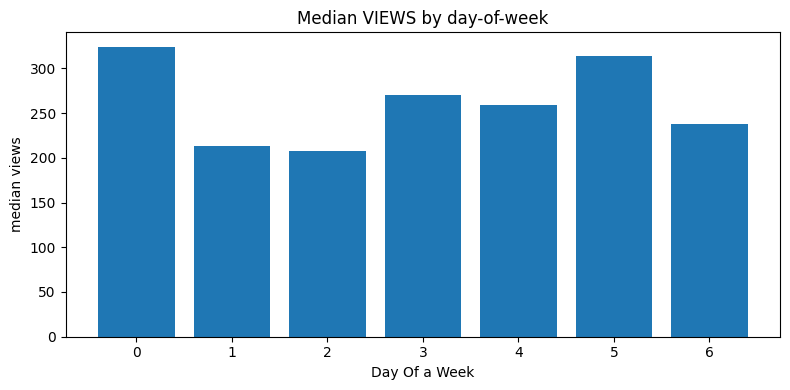

In [241]:
plt.figure(figsize=(8,4))
plt.bar(dow_stats["DOW"], dow_stats["views_median"])
plt.title("Median VIEWS by day-of-week")
plt.xlabel("Day Of a Week")
plt.ylabel("median views")
plt.tight_layout()
plt.show()

### 7. `CHANNEL_NAME` analysis (cardinality and frequency tail)

**What we do:** Measure number of unique channels and how many samples each channel has.

**Why it matters:** high-cardinality + many rare channels favors CatBoost and simple frequency features (e.g., `channel_freq`).

**Outcome:** understand overfitting risk and modeling implications for channels.

In [242]:
n_channels = df["CHANNEL_NAME"].nunique()
channel_counts = df["CHANNEL_NAME"].value_counts()

n_channels, channel_counts.head(10), channel_counts.describe(percentiles=[0.5,0.9,0.95,0.99])

(35957,
 CHANNEL_NAME
 likeatg              137
 banzaiauto125        127
 uiartemzvezdin       116
 dolgov_auto          115
 kutsenko_invest      112
 moex_arbitrage       110
 auto_zakazz25        105
 asia_express_auto    101
 tradervifree          98
 demwinner             94
 Name: count, dtype: int64,
 count    35957.000000
 mean         3.966098
 std          6.782957
 min          1.000000
 50%          2.000000
 90%          9.000000
 95%         15.000000
 99%         36.000000
 max        137.000000
 Name: count, dtype: float64)

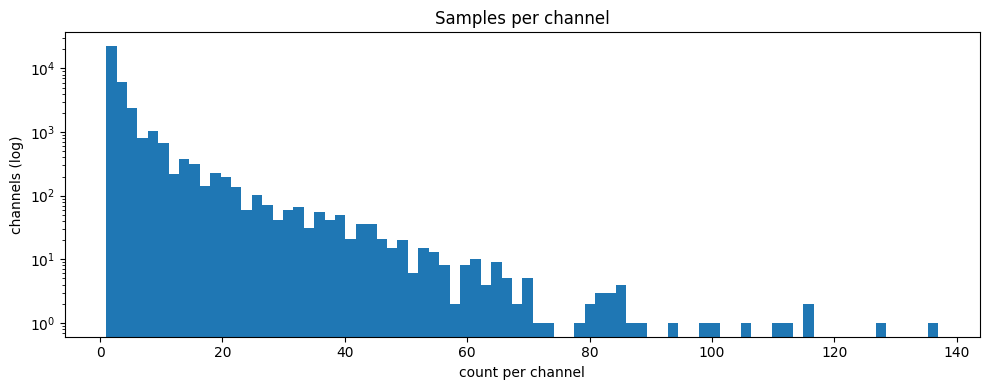

In [243]:
# Distribution of samples per channel (log-y to reveal long tail)
plt.figure(figsize=(10,4))
plt.hist(channel_counts.values, bins=80)
plt.yscale("log")
plt.title("Samples per channel")
plt.xlabel("count per channel")
plt.ylabel("channels (log)")
plt.tight_layout()
plt.show()

### 8. Collisions on (`CPM`, `CHANNEL_NAME`, `DATE`)

**What we do:** Check whether identical inputs appear multiple times with different `VIEWS`.

**Why it matters:** collisions indicate irreducible noise and limit achievable accuracy.

**Outcome:** quantify collision rate and within-key variability.

In [244]:
key = ["CPM", "CHANNEL_NAME", "DATE"]

# frequency of when the same key occur more than 1 time
counts = df.groupby(key)["VIEWS"].size()
collision_rate = (counts > 1).mean()

# variability of VIEWS within duplicate keys
ranges = (df.groupby(key)["VIEWS"].agg(lambda s: s.max() - s.min()))
ranges = ranges[ranges > 0]

print(f"Collision rate (same inputs repeated): {collision_rate:.3%}")
display(ranges.describe(percentiles=[0.5, 0.9, 0.95, 0.99]))

Collision rate (same inputs repeated): 8.120%


count      9517.000000
mean        585.856572
std        6839.112838
min           1.000000
50%          22.000000
90%         927.000000
95%        2001.200000
99%        9016.120000
max      612276.000000
Name: VIEWS, dtype: float64

### 9. Baseline metrics on a time split (last N days)

**What we do:** Evaluate simple baselines on a time holdout:
- `global_median`
- `dow_median`
- `channel_median_shrink`

**Why it matters:** baselines define a quality floor; ML must beat them.

**Outcome:** a reference table of metrics for sanity and comparison.

In [245]:
def split_last_days(data: pd.DataFrame, holdout_days: int = 30):
    dmax = data["DATE"].max()
    cutoff = dmax - timedelta(days=holdout_days)
    train = data.loc[data["DATE"] <= cutoff].copy()
    valid = data.loc[data["DATE"] > cutoff].copy()
    return train, valid, cutoff, dmax

def mae(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def rmsle(y_true, y_pred):
    y_true = np.clip(np.asarray(y_true, dtype=float), 0, None)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), 0, None)
    return float(np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true)) ** 2)))

def smape(y_true, y_pred, eps=1e-8):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denom = np.abs(y_true) + np.abs(y_pred) + eps
    return float(np.mean(2.0 * np.abs(y_pred - y_true) / denom))

In [246]:
metrics = {"MAE": mae, "RMSE": rmse, "RMSLE": rmsle, "SMAPE": smape}

train_df, valid_df, cutoff, dmax = split_last_days(df, holdout_days=30)
train_df.shape,  valid_df.shape, cutoff.date(), dmax.date()

((131923, 8),
 (10686, 8),
 datetime.date(2025, 11, 17),
 datetime.date(2025, 12, 17))

In [247]:
# Baseline 1: global median
y_valid = valid_df["VIEWS"].to_numpy(dtype=float)
global_median = float(train_df["VIEWS"].median())
pred_global = np.full_like(y_valid, fill_value=global_median, dtype=float)

In [248]:
# Baseline 2: median by day-of-week
train_dow = train_df["DATE"].dt.dayofweek
valid_dow = valid_df["DATE"].dt.dayofweek
dow_median = train_df.groupby(train_dow)["VIEWS"].median()
pred_dow = valid_dow.map(dow_median).fillna(global_median).to_numpy(dtype=float)

In [249]:
# Baseline 3: channel median with shrinkage to global median
alpha = 5
ch_stats = (train_df.groupby("CHANNEL_NAME")["VIEWS"]
            .agg(ch_median="median", ch_count="size")
            .reset_index())

valid_ch = valid_df[["CHANNEL_NAME"]].merge(ch_stats, on="CHANNEL_NAME", how="left")
w = (valid_ch["ch_count"] / (valid_ch["ch_count"] + alpha)).fillna(0.0)
pred_ch = (w * valid_ch["ch_median"].fillna(global_median) + (1 - w) * global_median).to_numpy(dtype=float)

In [250]:
baselines = {"global_median": pred_global, "dow_median": pred_dow, "channel_median_shrink": pred_ch}

rows = []
for name, pred in baselines.items():
    rows.append({"baseline": name, **{m: fn(y_valid, pred) for m, fn in metrics.items()}})

scores = pd.DataFrame(rows).sort_values("MAE")
scores

,baseline,MAE,RMSE,RMSLE,SMAPE
0,global_median,662.004398,5547.165818,2.124321,1.103390
1,dow_median,664.060453,5548.652700,2.134005,1.104632
2,channel_median_shrink,671.651889,5510.127151,2.044897,1.052407


### 10. Modeling conclusions and next steps

**Key decisions from EDA:**
1) `VIEWS` is heavy-tailed → train on `log1p(VIEWS)` and invert with `expm1` for more stable learning.
2) `CPM` is also heavy-tailed → add `log1p(CPM)` and clip extreme CPM values as features.
3) `CHANNEL_NAME` is high-cardinality/long-tailed → prefer models that handle categorical features well.
4) Data is non-stationary over time → validate with **time-based** splits (last N days; optionally rolling windows).

#### Why CatBoost
CatBoost is gradient boosting on decision trees with strong native support for categorical features:
- accepts categorical columns directly and uses ordered target statistics to reduce leakage/overfitting on rare categories;
- captures non-linearities and feature interactions well on tabular data;
- typically provides a strong baseline with minimal tuning and reasonable training speed.

**Next step:** train Model v1 in `EDA_models.ipynb` and compare it against the baselines from section 9.